In [1]:
import torch

In [2]:
# t_c - data in celcius, t_u - data in some unknown units

In [3]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

In [4]:
t_c_t = torch.tensor(t_c)
t_u_t = torch.tensor(t_u)

In [5]:
t_c_t.shape, t_u_t.shape, t_c_t.ndim, t_u_t.ndim, t_c_t.stride(), t_u_t.stride()

(torch.Size([11]), torch.Size([11]), 1, 1, (1,), (1,))

In [6]:
# assume the simple model here is t_c = w * t_u + b
# the weight tells us how much a given input influences the output. The bias is what the output would be if all inputs were zero

In [7]:
# we have a model with some unknown parameters, and we need to estimate those parameters so that
# the error between predicted outputs and measured values is as low as possible. We notice that we still need to exactly 
# define a measure of the error. Such a measure, which we refer to as the loss function (or cost function), should be high if the error is high and 
# should ideally be as low as possible for a perfect match. Our optimization process should therefore aim at finding w and b so that 
# the loss function is at a minimum

In [8]:
# t_p - predicted temperatures output by our model
# We need to make sure the loss function makes the loss positive, both when t_p is greater than and 
# when it is less than the true t_c because the goal is for t_p to match t_c.
# We have a few choices, the most straightforward being |t_p - t_c| and (t_p - t_c)^2

In [9]:
# Both of the example loss functions have a clear minimum at zero and grow monotonically 
# as the predicted value moves further from the true value in either direction.
# Because the steepness of the growth also monotonically increases away from the minimum, both are convex (ДУГООБРАЗНЫЕ). 
# Since our model is linear, the loss is a function of w, and b is also convex. 
# When our loss function is convex (shaped like a bowl), we could use specialized algorithms to efficiently find the minimum. 
# However, in this chapter, we’ll focus on two common, simple loss functions that work well across a variety of problems.
# While these fundamental approaches provide an excellent foundation, we’ll explore more sophisticated and specialized loss functions
# later when we work with deep neural networks that need to capture more complex relationships in the data

In [10]:
# t_u, w, and b to be the input tensor, weight parameter, and bias parameter, respectively. 
# In our model, the parameters will be PyTorch scalars (aka zero-dimensional tensors), 
# and the product operation will use broadcasting to yield the returned tensors.
def model(t_u, w, b):
    return w * t_u + b

In [11]:
# mean square loss
# result is scalar
def loss_fn(t_p, t_c):
    square_diffs = (t_p - t_c) ** 2
    return square_diffs.mean()

In [12]:
# w and b are scalars (zero-dimensional tensors)
w = torch.ones(())
b = torch.zeros(())
w, b

(tensor(1.), tensor(0.))

In [13]:
t_p_t = model(t_u_t, w, b)
t_p_t

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [14]:
loss = loss_fn(t_p_t, t_c_t)
loss

tensor(1763.8846)

## Broadcasting

In [15]:
# - For each index dimension, counted from the back, if one of the operands is size 1 in that dimension, 
# PyTorch will use the single entry along this dimension with each of the entries in the other tensor along this dimension.
# - If both sizes are greater than 1, they must be the same, and element-wise matching is used.
# - If one of the tensors has more index dimensions than the other, the entirety of the other tensor will be used for each entry along these dimensions.

In [16]:
x = torch.ones(())
y = torch.ones(3,1)
z = torch.ones(1,3)
a = torch.ones(2,1,1)
x,y,z,a

(tensor(1.),
 tensor([[1.],
         [1.],
         [1.]]),
 tensor([[1., 1., 1.]]),
 tensor([[[1.]],
 
         [[1.]]]))

In [17]:
print(f"shapes: x: {x.shape}, y: {y.shape}")
print(f"        z: {z.shape}, a: {a.shape}")

shapes: x: torch.Size([]), y: torch.Size([3, 1])
        z: torch.Size([1, 3]), a: torch.Size([2, 1, 1])


In [18]:
print("x*y: ", (x*y).shape)
print("y*z: ", (y*z).shape)
print("y*z*a: ", (y*z*a).shape)

x*y:  torch.Size([3, 1])
y*z:  torch.Size([3, 3])
y*z*a:  torch.Size([2, 3, 3])


## Loss function optimization. Gradient descent

In [19]:
# central difference approximation

In [20]:
delta = 0.1
loss_rate_of_change_w = (loss_fn(model(t_u_t, w + delta, b), t_c_t) - loss_fn(model(t_u_t, w - delta, b), t_c_t)) / 2.0 * delta
loss_rate_of_change_w

tensor(45.1730)

In [21]:
learning_rate = 1e-2
learning_rate

0.01

In [22]:
w = w - learning_rate*loss_rate_of_change_w
w

tensor(0.5483)

In [23]:
loss_rate_of_change_b = (loss_fn(model(t_u_t, w, b+delta), t_p_t) - loss_fn(model(t_u_t, w, b-delta), t_p_t)) / 2.0*delta
loss_rate_of_change_b

tensor(-0.4680)

In [24]:
b = b - learning_rate*loss_rate_of_change_b
b

tensor(0.0047)

In [25]:
# direvative of loss - how the loss changes when a prediction changes

In [26]:
# This function returns a tensor where each element represents how much the loss would change if we slightly adjusted the corresponding prediction. 
# The factor of 2 comes from the power rule for differentiation, 
# while the division by t_p.size(0) accounts for the averaging operation in the original loss function.
def dloss_fn(t_p, t_c):
    dsq_diffs = 2*(t_p - t_c) / t_p.size(0) # The division using t_p.size(0) is the number of elements for t_p.
    return dsq_diffs

In [27]:
dloss_fn(t_p_t, t_c_t)

tensor([6.4000, 7.6182, 7.8545, 9.8000, 8.2364, 7.4364, 5.6182, 4.6909, 7.7091,
        8.6182, 8.6182])

### Applying the derivatives to the model

In [28]:
# derivatives of the model:
# with respect to w
# and with respect to b

In [29]:
def dmodel_dw(t_u, w, b):
    return t_u

In [30]:
def dmodel_db(t_u, w, b):
    return 1

### Gradient function

In [31]:
# the function returning the gradient of the loss with respect to w and b is

In [32]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

### Iterating to fit the model

In [33]:
# epoc vs training iteration (step)
# In deep learning, an epoch refers to a complete pass through the entire training dataset, 
# where all samples have been used once to update the model parameters. 
# An epoch is different from a single training iteration (or step), 
# which typically involves processing one batch of data through forward and backward passes. 
# With our current implementation, we’re using the entire dataset in each iteration, so one iteration equals one epoch. 
# In larger datasets, we’ll typically split data into batches, requiring multiple iterations to complete a single epoch

In [34]:
def training_loop(t_u, t_c, params, learning_rate, nepoch, print_params=True):
    for epoch in range(1, nepoch+1):
        w,b = params
        t_p = model(t_u, w, b) # forward pass
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b) # backward pass
        # print('Epoch : %d, Loss: %f, params: %s, grad: %s' % (epoch, float(loss), params, grad)) 
        params = params - learning_rate * grad
        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:  # <3>
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            if print_params:
                print('    Params:', params)
                print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

        if not torch.isfinite(loss).all():
            break  # <3>
    return params

In [35]:
# we see overfitting
training_loop(
    t_u=t_u_t,
    t_c=t_c_t,
    params=torch.tensor([1.0, 0.0]),
    learning_rate=1e-2,
    nepoch=100
)

Epoch 1, Loss 1763.884644
    Params: tensor([-44.1730,  -0.8260])
    Grad:   tensor([4517.2964,   82.6000])
Epoch 2, Loss 5802484.500000
    Params: tensor([2568.4011,   45.1637])
    Grad:   tensor([-261257.4062,   -4598.9707])
Epoch 3, Loss 19408033792.000000
    Params: tensor([-148527.7344,   -2616.3931])
    Grad:   tensor([15109614.0000,   266155.6875])
...
Epoch 10, Loss 90901124996059702376382357942829056.000000
    Params: tensor([3.2144e+17, 5.6621e+15])
    Grad:   tensor([-3.2700e+19, -5.7600e+17])
Epoch 11, Loss inf
    Params: tensor([-1.8590e+19, -3.2746e+17])
    Grad:   tensor([1.8912e+21, 3.3313e+19])


tensor([-1.8590e+19, -3.2746e+17])

### hyperparameter tuning

In [36]:
# lets decrease a learning rate from 1e-2 to 1e-4

In [37]:
# now there’s another problem: the updates to parameters are very small, so the loss decreases very slowly and eventually stalls. 
# We could obviate this problem by making learning_rate adaptive—that is, change according to the magnitude of updates. 
# There are optimization schemes that do that
training_loop(
    t_u=t_u_t,
    t_c=t_c_t,
    params=torch.tensor([1.0, 0.0]),
    learning_rate=1e-4,
    nepoch=100
)

Epoch 1, Loss 1763.884644
    Params: tensor([ 0.5483, -0.0083])
    Grad:   tensor([4517.2964,   82.6000])
Epoch 2, Loss 323.090546
    Params: tensor([ 0.3623, -0.0118])
    Grad:   tensor([1859.5492,   35.7843])
Epoch 3, Loss 78.929634
    Params: tensor([ 0.2858, -0.0135])
    Grad:   tensor([765.4666,  16.5122])
...
Epoch 10, Loss 29.105247
    Params: tensor([ 0.2324, -0.0166])
    Grad:   tensor([1.4803, 3.0544])
Epoch 11, Loss 29.104168
    Params: tensor([ 0.2323, -0.0169])
    Grad:   tensor([0.5781, 3.0384])
...
Epoch 99, Loss 29.023582
    Params: tensor([ 0.2327, -0.0435])
    Grad:   tensor([-0.0533,  3.0226])
Epoch 100, Loss 29.022669
    Params: tensor([ 0.2327, -0.0438])
    Grad:   tensor([-0.0532,  3.0226])


tensor([ 0.2327, -0.0438])

### normalizing inputs

In [38]:
# 1st epoch gradient for weight is 50 times higher than the gradient for the bias which is a problem
# solution is to normalize the inputs so t_u is inisde [-1.0, 1.0]
t_u_t_norm = 0.1 * t_u_t

In [39]:
params = training_loop(
    t_u=t_u_t_norm,
    t_c=t_c_t,
    params=torch.tensor([1.0, 0.0]),
    learning_rate=1e-2,
    nepoch=5000,
    print_params = False
)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574917
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941875
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148712
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927647


In [40]:
# Good, our loss decreases while we change parameters along the direction of gradient descent.

In [41]:
%matplotlib inline

In [42]:
from matplotlib import pyplot as plt

In [43]:
params

tensor([  5.3671, -17.3012])

In [44]:
t_p_t = model(t_u_t_norm, *params) # we use argument unpacking here

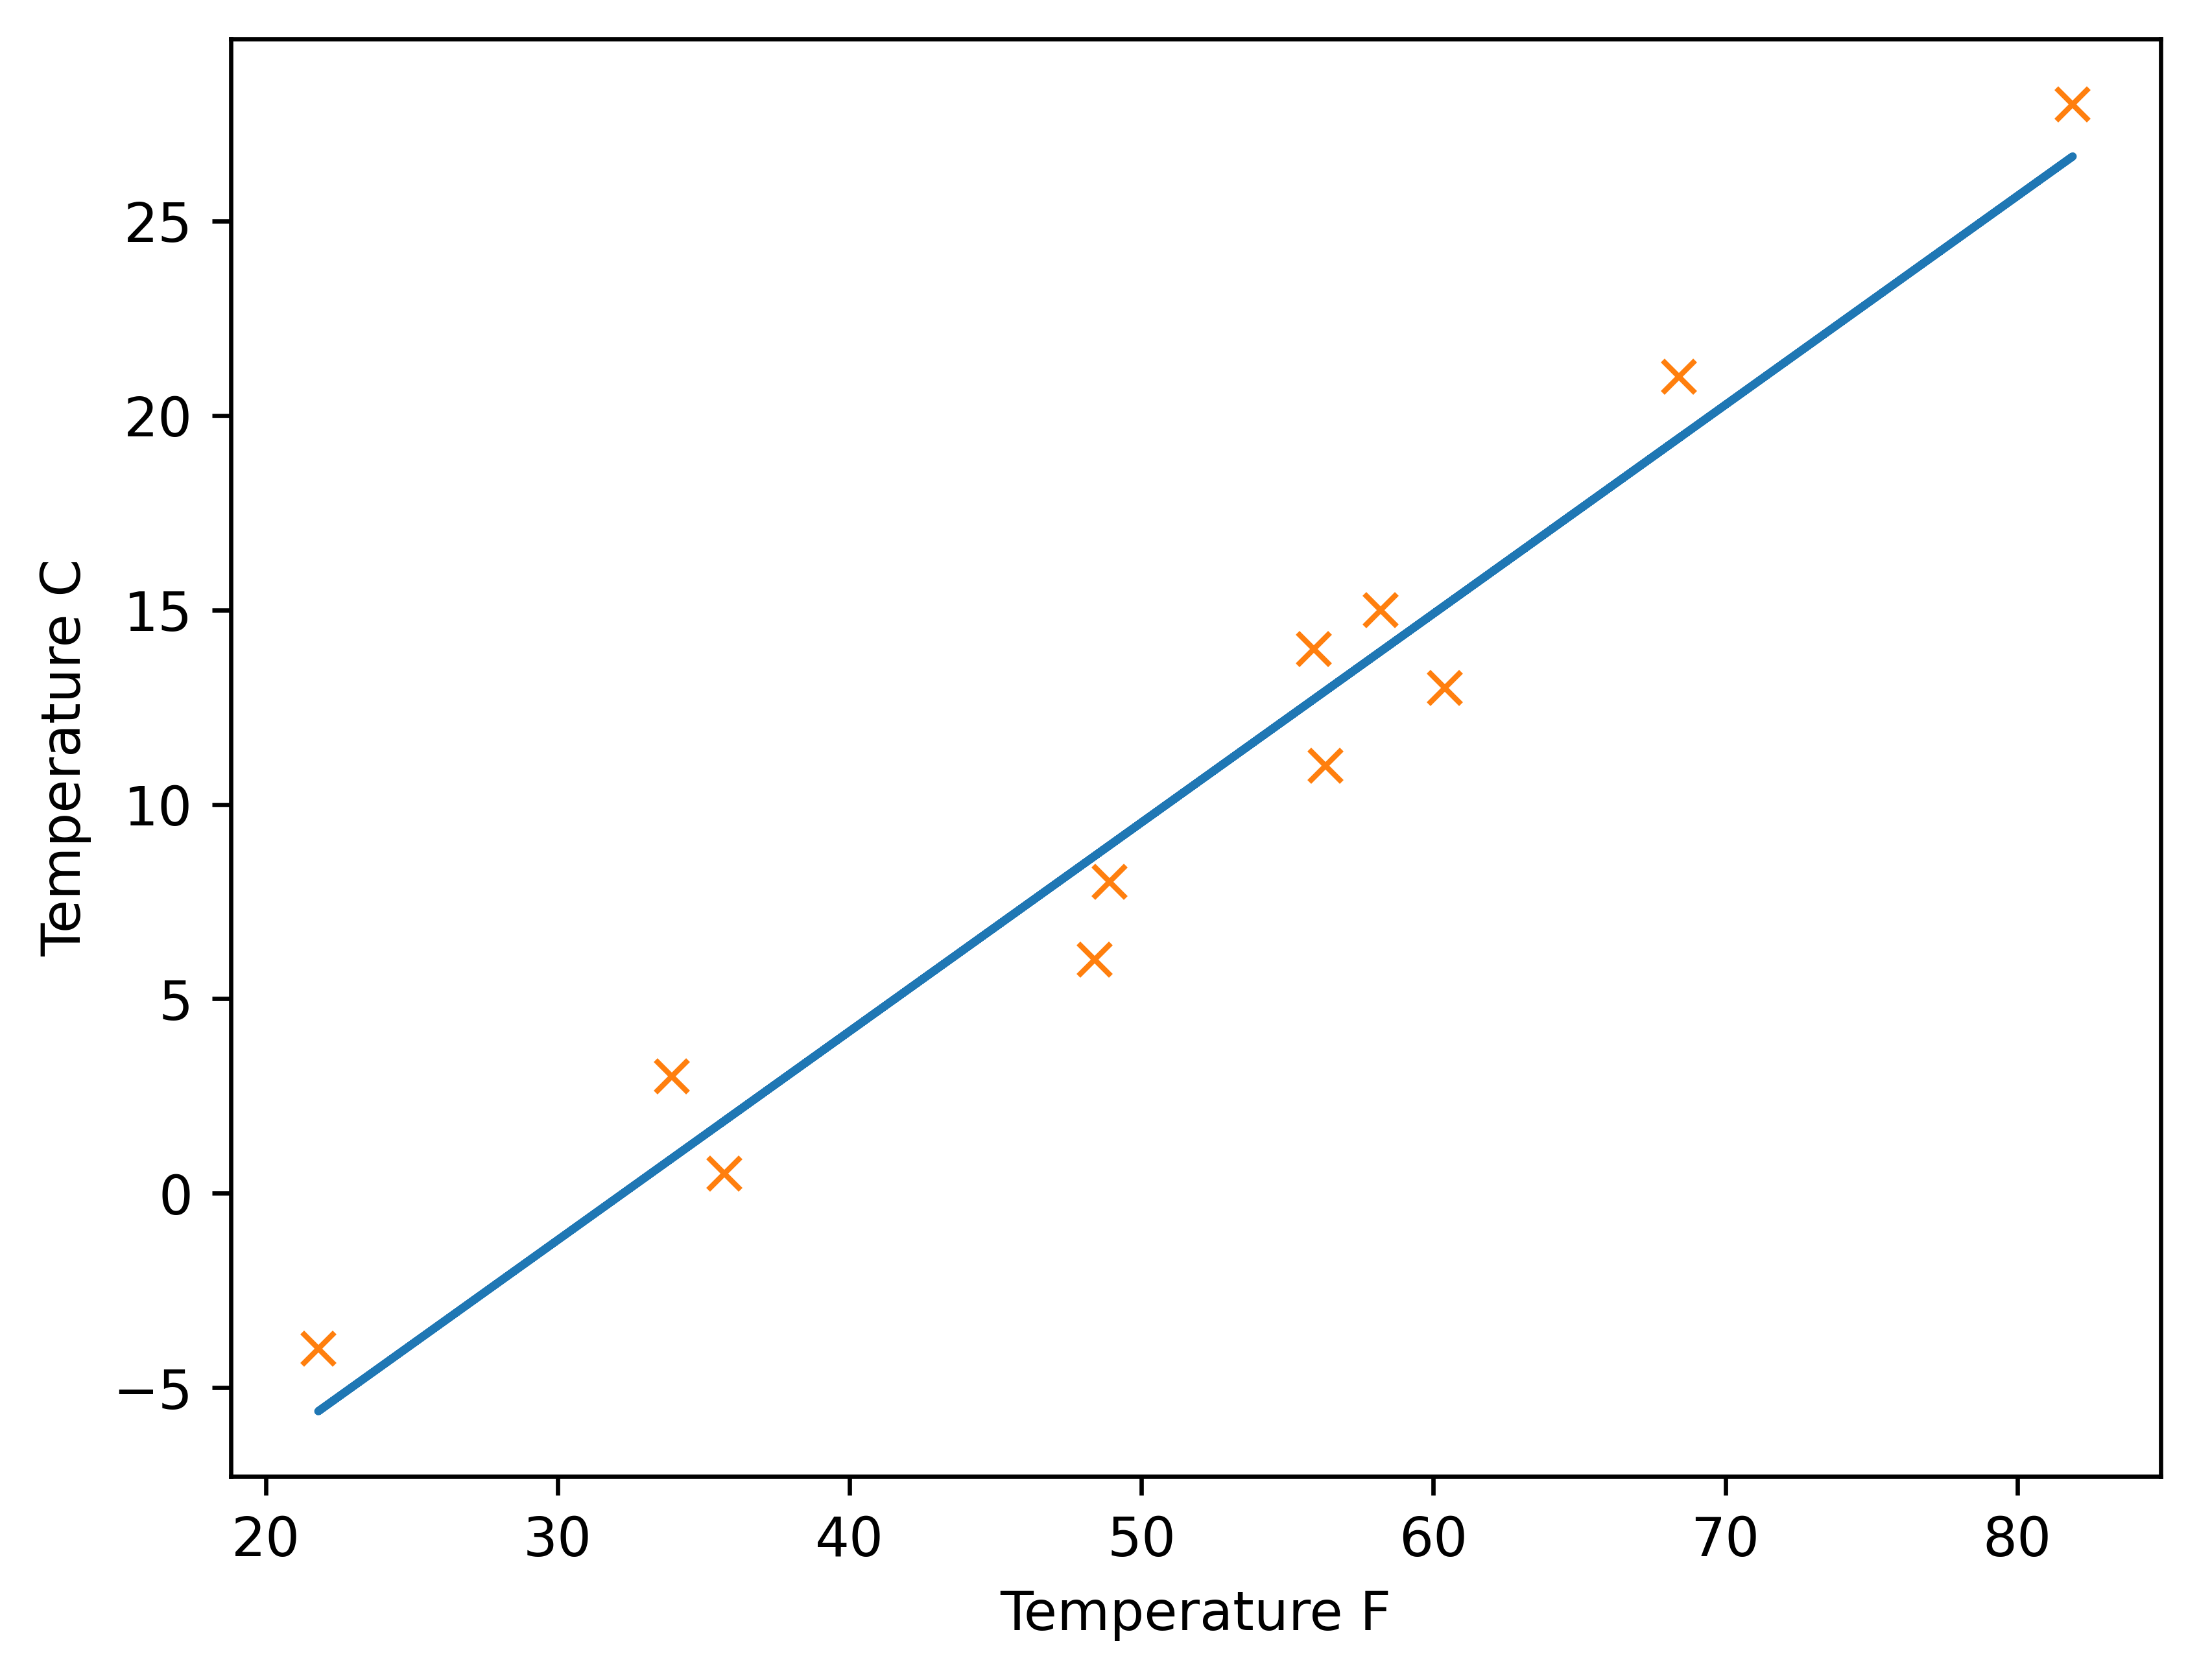

In [45]:
fig = plt.figure(dpi=600)
plt.xlabel("Temperature F")
plt.ylabel("Temperature C")
plt.plot(t_u_t.numpy(), t_p_t.detach().numpy())
plt.plot(t_u_t.numpy(), t_c_t.numpy(), 'x')

## PyTorch Autograd (no need to compute derivatives by hand)

In [46]:
# backpropagation - обратное распространение ошибок

In [47]:
# we just saw a simple example of backpropagation: we computed the gradient of a composition of functions—the model and 
# the loss—with respect to their innermost parameters (w and b) by propagating derivatives backward using the chain rule.
# The basic requirement here is that all functions we’re dealing with can be differentiated analytically.
# If this is the case, we can compute the gradient—what we earlier called “the rate of change of the loss”—with respect to the parameters in one sweep

In [48]:
# PyTorch tensors can remember where they come from, in terms of the operations and parent tensors that originated them, 
# and they can automatically provide the chain of derivatives of such operations with respect to their inputs. 
# Consequently, we won’t need to derive our model by hand given a forward expression, because, no matter how nested, 
# PyTorch will automatically provide the gradient of that expression with respect to its input parameters.

### Applying Autograd

In [49]:
def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    square_diffs = (t_p - t_c)**2
    return square_diffs.mean()

params = torch.tensor([1.0, 0.0], requires_grad=True)

In [50]:
# requires_grad - that argument is telling PyTorch to track the entire family tree of tensors resulting from operations on params.

In [51]:
# That argument is telling PyTorch to track the entire family tree of tensors resulting from operations on params. 
# In other words, any tensor that will have params as an ancestor will have access to the chain of functions that were called to get from params 
# to that tensor. In case these functions are differentiable (and most PyTorch tensor operations will be),
# the value of the derivative will be automatically populated as a grad attribute of the params tensor

In [52]:
params.grad

In [53]:
loss = loss_fn(model(t_u_t, *params), t_c_t)
loss.backward()
params.grad

tensor([4517.2964,   82.6000])

In [54]:
# At this point, the grad attribute of params contains the derivatives of the loss with respect to each element of params

In [55]:
# Calling backward will lead derivatives to accumulate at leaf nodes. We need to zero the gradient explicitly after using it for parameter updates.

In [56]:
#  we need to zero the gradient explicitly at each iteration as derivatives are accumulating at leaf nodes at each iteration that leads to incorrect gradient

In [57]:
if params.grad is not None:
    params.grad.zero_() # grad is a tensor so zero_() fills the tensor in place with zeros

In [58]:
params.grad

tensor([0., 0.])

### autograd-enabled training loop

In [71]:
def training_loop(t_u, t_c, learning_rate=0.01, nepoch=5000, params=[1.0,0.0], print_params=True):
    for epoch in range(1,nepoch+1):
        t_p = model(t_u, *params)
        if params.grad is not None:
            params.grad.zero_()    # we need to put anywhere before the backward() call
        loss = loss_fn(t_p, t_c)
        loss.backward()

        # encapsulating the update in a no_grad context using the Python with statement. 
        # So, within the with block, the PyTorch autograd mechanism should look away — that is, not add edges to the forward graph
        # (in reality, it will track that something changed params using an in-place operation).
        # In fact, when we are executing this bit of code, the forward graph that PyTorch records is consumed when we call backward, 
        # leaving us with the params leaf node. But now we want to change this leaf node before we start building a fresh forward graph on top of it.
    
        with torch.no_grad():
            # When using autograd, we usually avoid in-place updates because 
            # PyTorch’s autograd engine might need the values we would be modifying for the backward pass
            # Here, however, we are operating within the torch.no_grad() context where autograd tracking 
            # is disabled for the parameter update, so it’s safe to modify the params tensor in place.
            params -= learning_rate * params.grad
        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:  # <3>
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            if print_params:
                print('    Params:', params)
                print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

        if not torch.isfinite(loss).all():
            break
    return params

In [73]:
params = training_loop(
    t_u=t_u_t_norm,
    t_c=t_c_t,
    params=torch.tensor([1.0, 0.0], requires_grad=True),
    learning_rate=1e-2,
    nepoch=5000,
    print_params = False
)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574917
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941875
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148712
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927647
